In [10]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,Annotated
from pydantic import BaseModel,Field
import operator
from langchain_core.messages import (HumanMessage,SystemMessage,AIMessage,BaseMessage)
from langgraph.checkpoint.memory import MemorySaver


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

e:\Langchain\langchain-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
#llama-3.3-70b-versatile
model = ChatGroq(model="llama-3.3-70b-versatile",temperature=0.7)

In [5]:
# add_message
from langgraph.graph.message import add_messages

class ChatbotState(TypedDict):
    conversation: Annotated[list[BaseMessage],add_messages]

In [6]:
def chat_with_llm(state:ChatbotState) :

    conversation = state["conversation"]
    
    response = model.invoke(conversation)


    return {"conversation":[response]}


In [11]:
checkpointer = MemorySaver()


graph = StateGraph(ChatbotState)

graph.add_node("chat_with_llm" , chat_with_llm)

graph.add_edge(START,"chat_with_llm")
graph.add_edge("chat_with_llm",END)

chatbot = graph.compile(checkpointer=checkpointer)

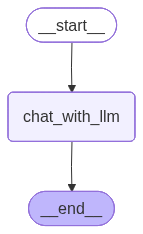

In [12]:
chatbot

In [14]:
initial_state = {'conversation':[HumanMessage(content="Who is Elon Musk ?")]}

In [16]:
chatbot.invoke(initial_state)['conversation'][-1].content

"Elon Musk is a South African-born entrepreneur, inventor, and business magnate. He is best known for his ambitious goals and innovative ventures in the fields of electric cars, space exploration, renewable energy, and artificial intelligence.\n\n**Early Life and Education:**\nElon Musk was born on June 28, 1971, in Pretoria, South Africa. He developed an interest in computing and programming at an early age and taught himself computer programming. Musk moved to Canada in 1992 to attend college and later transferred to the University of Pennsylvania, where he graduated with a degree in economics and physics.\n\n**Career:**\nMusk's career can be divided into several phases:\n\n1. **Zip2 and X.com**: Musk's first company, Zip2, provided online content publishing software for news organizations. He sold the company in 1999 and used the funds to co-found X.com, which later became PayPal, an online payment system.\n2. **SpaceX**: In 2002, Musk founded SpaceX, with the goal of reducing space

In [13]:
thread_id = '1'

while True:

    user_query = input("Chat with your AI Assistant..")

    if user_query.strip().lower() in ["bye","exit"] :
        break

    print(f"User : {user_query}")

    config = {"configurable":{'thread_id':thread_id}}

    response = chatbot.invoke({'conversation':[HumanMessage(content=user_query)]},config=config)

    print(f"AI assistant: {response['conversation'][-1].content} ")

User : Hey Hi
AI assistant: It's nice to meet you. Is there something I can help you with or would you like to chat? 
User : I am Ajax. AI engineer at Open AI
AI assistant: Nice to meet you, Ajax. That's really cool that you're an AI engineer at OpenAI. They're doing some amazing work in the field of artificial intelligence. What specific areas of AI are you working on? Are you involved in any of the language model development, like the ones that power chatbots like me? 
User : who am I ?
AI assistant: You are Ajax, an AI engineer at OpenAI. You introduced yourself as such earlier in our conversation. Is there something more you'd like to share about yourself or your work? 
User : no thanks. It was nice talking to you. Bye
AI assistant: It was nice talking to you too, Ajax. Have a great day and good luck with your work at OpenAI. Bye! 


In [14]:
print(chatbot.get_state(config=config))

StateSnapshot(values={'conversation': [HumanMessage(content='Hey Hi', additional_kwargs={}, response_metadata={}, id='732334e9-8667-4abb-8c54-0ae2b1804bf5'), AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 37, 'total_tokens': 60, 'completion_time': 0.055511915, 'completion_tokens_details': None, 'prompt_time': 0.001958761, 'prompt_tokens_details': None, 'queue_time': 0.048564213, 'total_time': 0.057470676}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d39c7-18c1-7ac1-af8f-78743e59ef01-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 23, 'total_tokens': 60}), HumanMessage(content='I am Ajax. AI engineer at Open AI', additional_kwargs={},